In [1]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [2]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

cuda
True
Tesla T4


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [6]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

Epoch [1/15] Train Acc: 84.64% Test Acc: 90.02% Best Test Acc: 90.02%
Epoch [2/15] Train Acc: 90.44% Test Acc: 89.99% Best Test Acc: 90.02%
Epoch [3/15] Train Acc: 91.69% Test Acc: 92.16% Best Test Acc: 92.16%
Epoch [4/15] Train Acc: 92.62% Test Acc: 92.01% Best Test Acc: 92.16%
Epoch [5/15] Train Acc: 93.30% Test Acc: 92.55% Best Test Acc: 92.55%
Epoch [6/15] Train Acc: 93.92% Test Acc: 92.05% Best Test Acc: 92.55%
Epoch [7/15] Train Acc: 94.47% Test Acc: 92.78% Best Test Acc: 92.78%
Epoch [8/15] Train Acc: 95.97% Test Acc: 93.35% Best Test Acc: 93.35%
Epoch [9/15] Train Acc: 96.53% Test Acc: 93.31% Best Test Acc: 93.35%
Epoch [10/15] Train Acc: 96.87% Test Acc: 93.33% Best Test Acc: 93.35%
Epoch [11/15] Train Acc: 97.31% Test Acc: 93.29% Best Test Acc: 93.35%
Epoch [12/15] Train Acc: 97.53% Test Acc: 93.39% Best Test Acc: 93.39%
Epoch [13/15] Train Acc: 97.80% Test Acc: 93.36% Best Test Acc: 93.39%
Epoch [14/15] Train Acc: 98.08% Test Acc: 93.33% Best Test Acc: 93.39%
Epoch [15/15] T

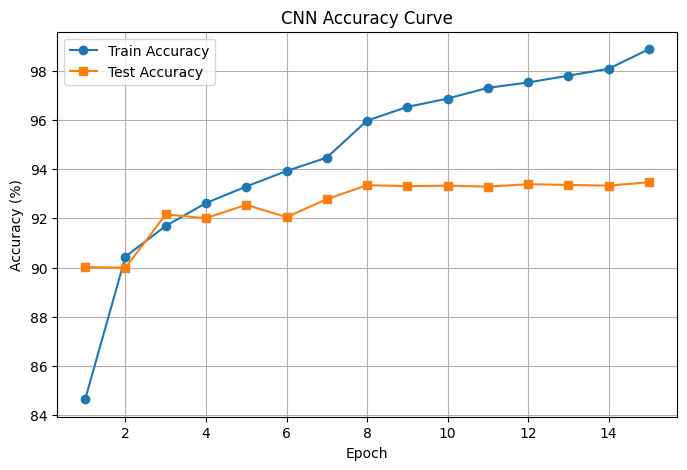

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================
# 1. 모델 새로 초기화
# =========================

model = FashionCNN().to(device)   # 네 CNN class 이름이 다르면 여기만 수정
criterion = nn.CrossEntropyLoss()

# =========================
# 2. 학습 설정
# =========================

epochs = 15

train_acc_list = []
test_acc_list = []

best_test_acc = 0.0
best_epoch = 0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.5
)

# =========================
# 3. 학습 시작
# =========================

for epoch in range(epochs):
    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total
    train_acc_list.append(train_acc)

    # =========================
    # 4. 테스트 평가
    # =========================

    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total
    test_acc_list.append(test_acc)

    # 최고 성능 저장
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_cnn_model.pth")

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Acc: {test_acc:.2f}% "
        f"Best Test Acc: {best_test_acc:.2f}%"
    )

print(f"\n최고 성능: Epoch {best_epoch}, Test Acc: {best_test_acc:.2f}%")

# =========================
# 5. 정확도 그래프 출력
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_acc_list,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    range(1, epochs + 1),
    test_acc_list,
    marker='s',
    label='Test Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('CNN Accuracy Curve')
plt.legend()
plt.grid(True)

plt.show()